# Sathwik TV
# Data Science Intern — Oasis Infobyte
# Task: Unemployment Analysis with Python

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)
print("Files in dataset:", os.listdir(path))

Path to dataset files: C:\Users\sathw\.cache\kagglehub\datasets\gokulrajkmv\unemployment-in-india\versions\5
Files in dataset: ['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [8]:
csv = os.path.join(path, "Unemployment in India.csv")
covid_csv = os.path.join(path, "Unemployment_Rate_upto_11_2020.csv")

In [9]:

df = pd.read_csv(csv)
covid_df = pd.read_csv(covid_csv)

In [10]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
covid_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


**DF**

In [12]:
df.tail()   

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

df.columns

Index(['region', 'date', 'frequency', 'estimated_unemployment_rate_(%)',
       'estimated_employed', 'estimated_labour_participation_rate_(%)',
       'area'],
      dtype='str')

In [14]:
df['date'] = pd.to_datetime(df['date'].str.strip(), format='%d-%m-%Y')

In [15]:
df.shape

(768, 7)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   region                                   740 non-null    str           
 1   date                                     740 non-null    datetime64[us]
 2   frequency                                740 non-null    str           
 3   estimated_unemployment_rate_(%)          740 non-null    float64       
 4   estimated_employed                       740 non-null    float64       
 5   estimated_labour_participation_rate_(%)  740 non-null    float64       
 6   area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 58.0 KB


In [17]:
df.isnull().sum()

region                                     28
date                                       28
frequency                                  28
estimated_unemployment_rate_(%)            28
estimated_employed                         28
estimated_labour_participation_rate_(%)    28
area                                       28
dtype: int64

In [18]:
df = df.dropna(how='all').reset_index(drop=True)
df.isnull().sum()

region                                     0
date                                       0
frequency                                  0
estimated_unemployment_rate_(%)            0
estimated_employed                         0
estimated_labour_participation_rate_(%)    0
area                                       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [21]:
df['date'].min(), df['date'].max()

(Timestamp('2019-05-31 00:00:00'), Timestamp('2020-06-30 00:00:00'))

In [22]:
df['frequency']=df['frequency'].str.strip()
df['frequency'].unique()


<ArrowStringArray>
['Monthly']
Length: 1, dtype: str

In [23]:
df.shape

(740, 7)

In [24]:
nm_df=df.select_dtypes(include=np.number,)
ct_df=df.select_dtypes(include=object).drop(columns=['frequency'])

C:\Users\sathw\AppData\Local\Temp\ipykernel_20208\100130399.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ct_df=df.select_dtypes(include=object).drop(columns=['frequency'])


**EDA_DF**

*numerical*

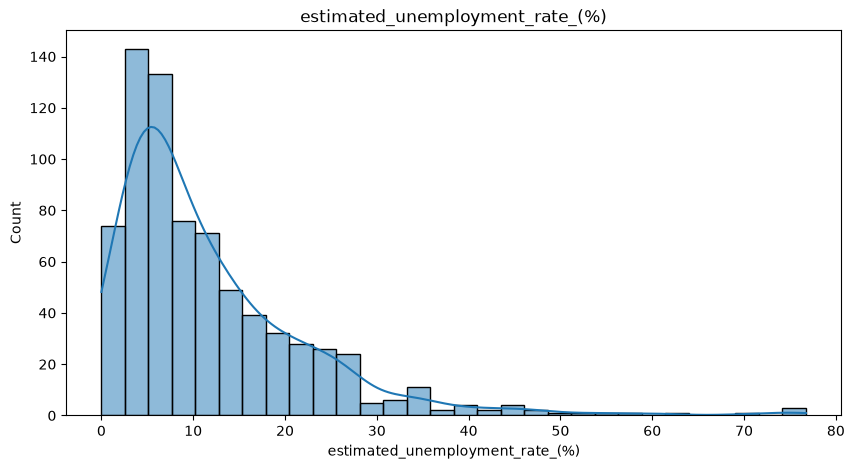

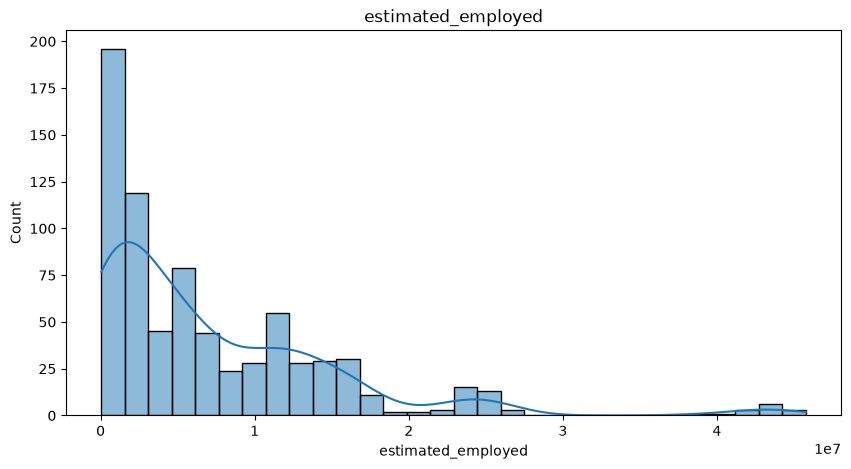

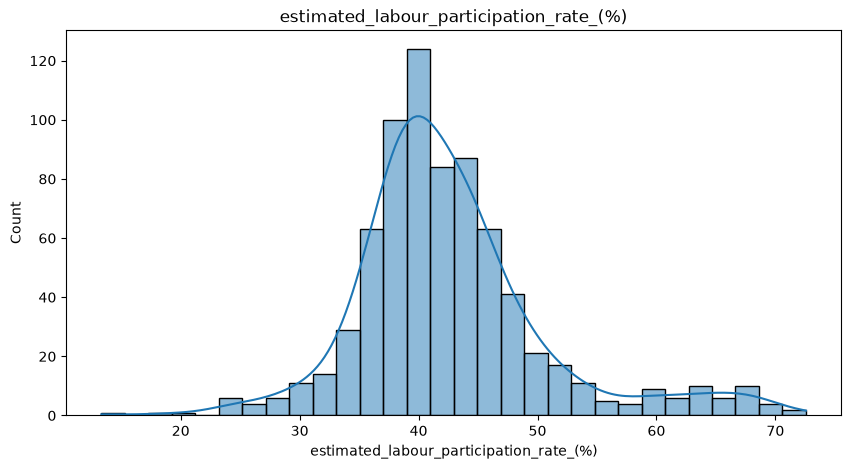

In [25]:
for col in nm_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(nm_df[col], kde=True, bins=30)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(col)
    plt.show()
    plt.close()

**Insight:** Unemployment rate is heavily right-skewed — most values fall between 0-15% (median ~8%), with a long tail stretching to ~77%. Estimated employed is also right-skewed, largely reflecting state population size rather than a meaningful standalone distribution. Labour participation rate is roughly bell-shaped, centered around 40%.

In [26]:
df[nm_df.columns].skew()

estimated_unemployment_rate_(%)            2.217921
estimated_employed                         2.049821
estimated_labour_participation_rate_(%)    1.031480
dtype: float64

*BOXPLOT*

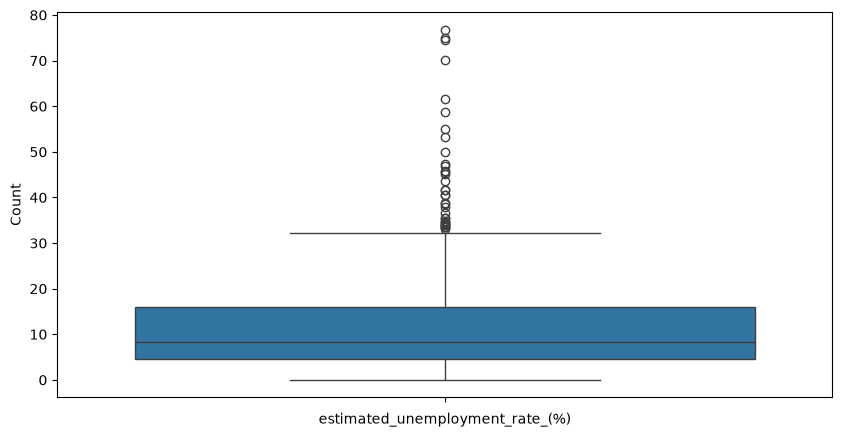

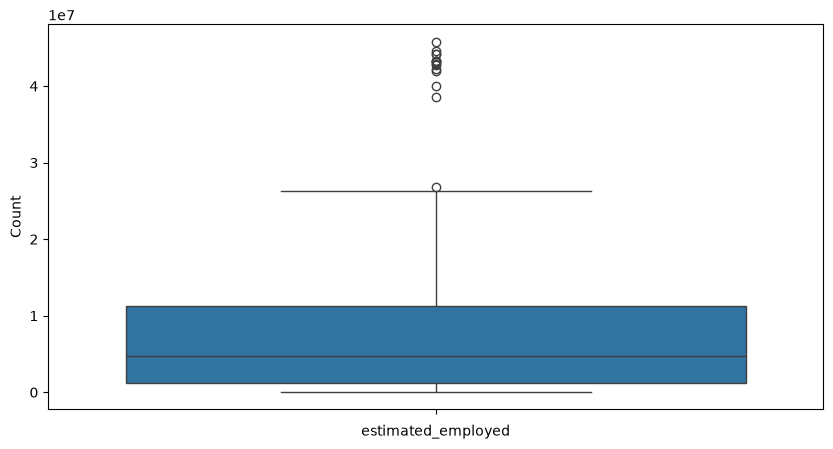

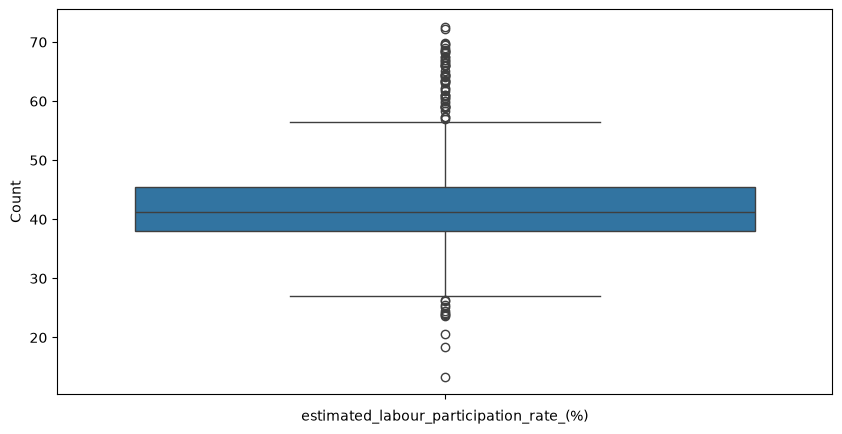

In [27]:
for col in nm_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(nm_df[col])
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Insight:** Boxplots confirm the skew seen above — `estimated_unemployment_rate_(%)` has a dense cluster of outliers above ~32%, meaning extreme unemployment spikes are common enough not to be dismissed as noise. `estimated_employed` outliers above ~2.6 crore correspond to India's largest states by population. `estimated_labour_participation_rate_(%)` is comparatively tight, with only a handful of low outliers below 20%.

*Scatterplots*

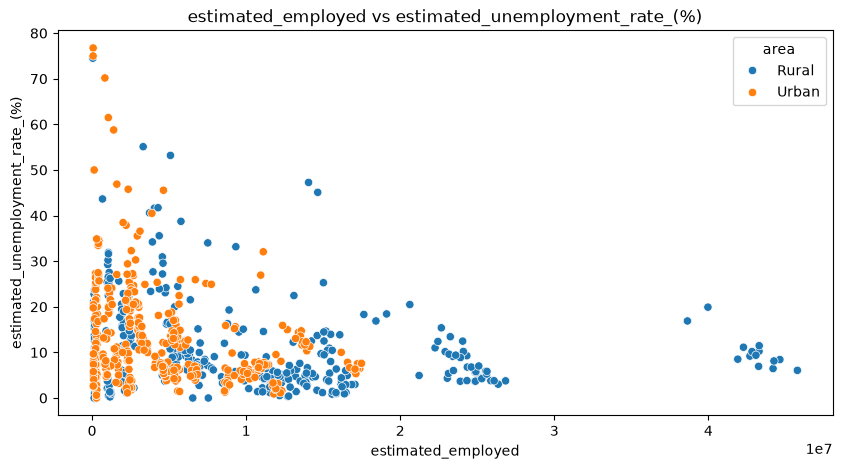

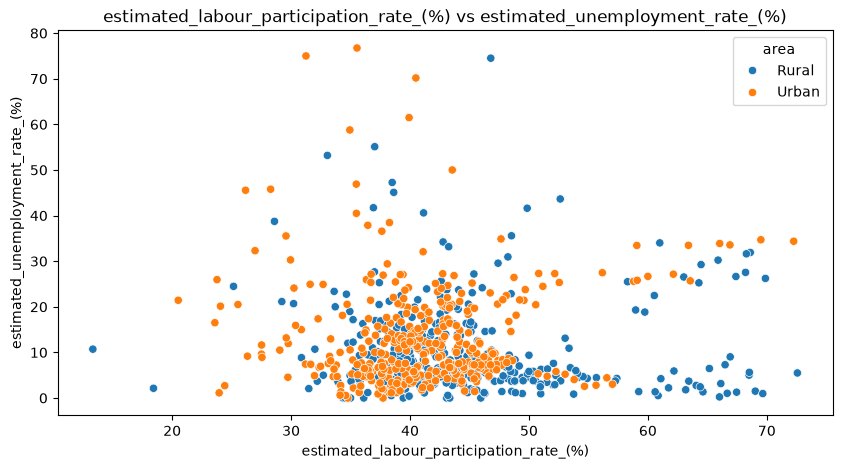

In [28]:
target = 'estimated_unemployment_rate_(%)'

for col in nm_df.columns:
    if col == target:
        continue
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x=col, y=target, hue='area')
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f'{col} vs {target}')
    plt.show()
    plt.close()

**Insight:** No clean linear relationship is visible between unemployment rate and either `estimated_employed` or `estimated_labour_participation_rate_(%)`. High-employment states cluster at low unemployment, but this is more likely explained by population size than a direct causal link — worth computing an actual correlation coefficient before claiming a relationship. Rural and Urban points overlap heavily rather than forming separate clusters.

*Categorical columns*

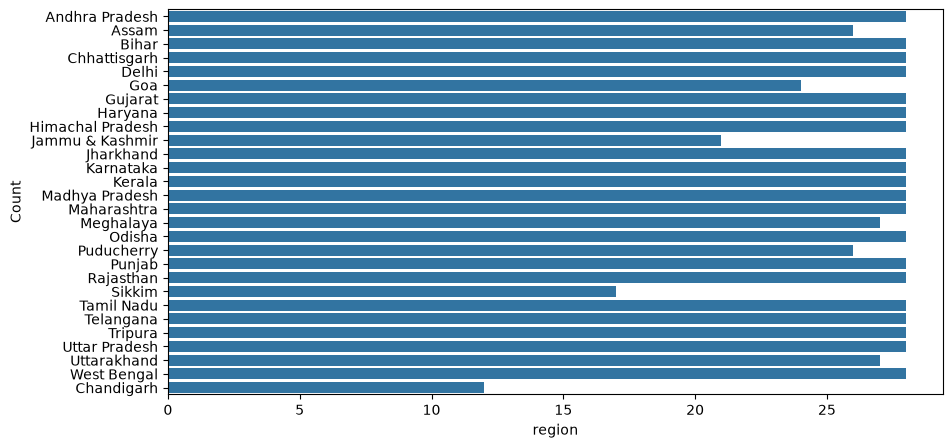

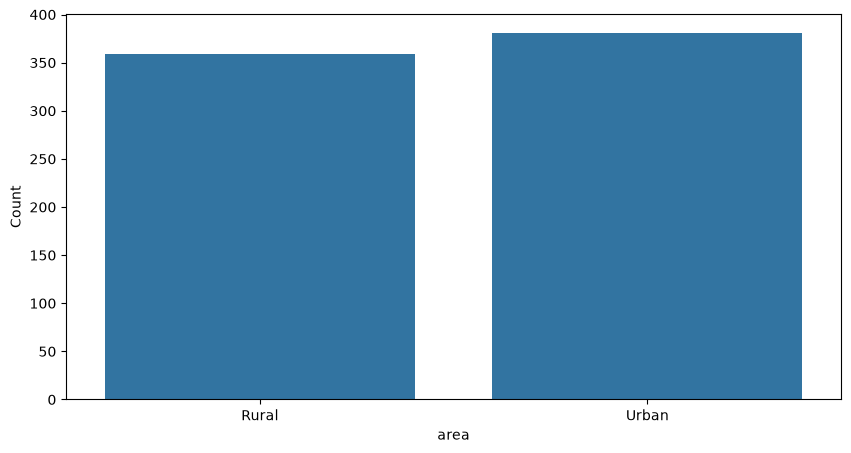

In [29]:
for col in ct_df.columns:
    plt.figure(figsize=(10, 5))
    if col == 'region':
        sns.countplot(data=ct_df, y=col)
    else:
        sns.countplot(data=ct_df, x=col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Insight:** Region counts are mostly ~28 (consistent monthly coverage across the period), but Sikkim (17), Chandigarh (12), and Jammu & Kashmir (21) have visibly fewer records — missing months for these regions. This matters if computing region-wise averages later, since fewer data points means less reliable numbers for those specific states. **Bug found:** the `frequency` chart shows two separate "Monthly" bars — the column *names* were stripped of whitespace earlier, but the *values inside* `frequency` were not, so `"Monthly"` and `" Monthly"` are being counted as different categories. Fix with `df['frequency'] = df['frequency'].str.strip()` before re-plotting.

region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: estimated_unemployment_rate_(%), dtype: float64


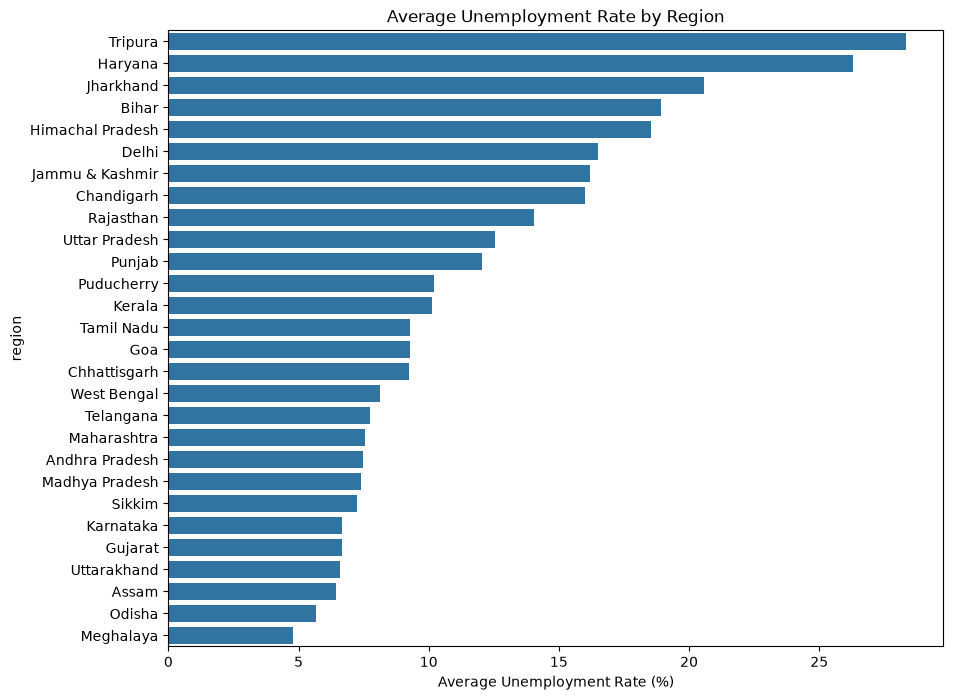

In [30]:
region_avg = df.groupby("region")["estimated_unemployment_rate_(%)"].mean().sort_values(ascending=False)
print(region_avg)

plt.figure(figsize=(10, 8))
sns.barplot(x=region_avg.values, y=region_avg.index)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.show()

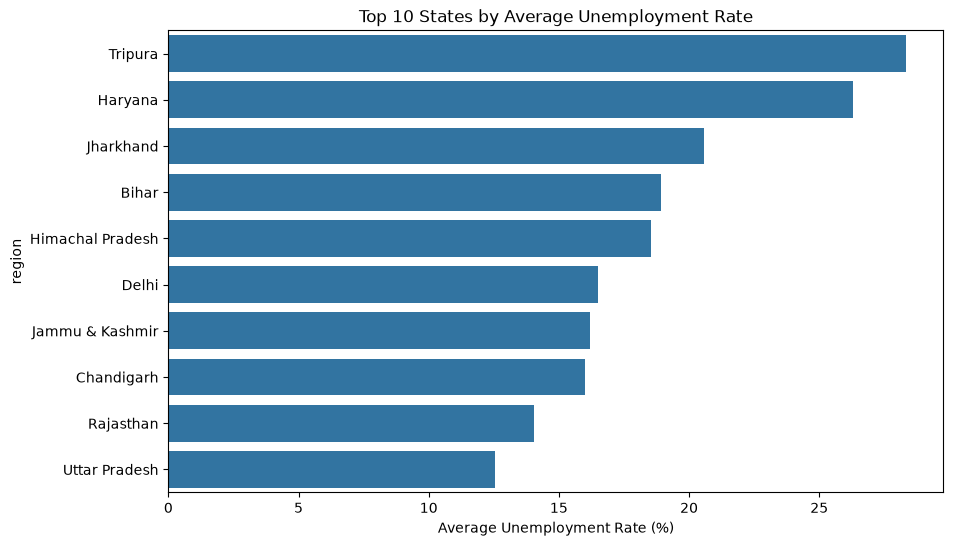

In [31]:
top10_states = df.groupby("region")["estimated_unemployment_rate_(%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_states.values, y=top10_states.index)
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.show()

Pre-COVID average unemployment rate: 9.61%
Post-COVID average unemployment rate: 20.19%
Change: +10.58 percentage points


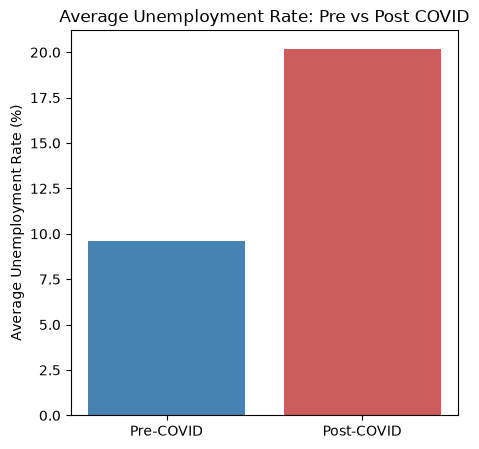

In [32]:
pre_covid = df[df["date"] < "2020-04-01"]["estimated_unemployment_rate_(%)"].mean()
post_covid = df[df["date"] >= "2020-04-01"]["estimated_unemployment_rate_(%)"].mean()

print(f"Pre-COVID average unemployment rate: {pre_covid:.2f}%")
print(f"Post-COVID average unemployment rate: {post_covid:.2f}%")
print(f"Change: {post_covid - pre_covid:+.2f} percentage points")

plt.figure(figsize=(5,5))
plt.bar(["Pre-COVID", "Post-COVID"], [pre_covid, post_covid], color=["steelblue", "indianred"])
plt.title("Average Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

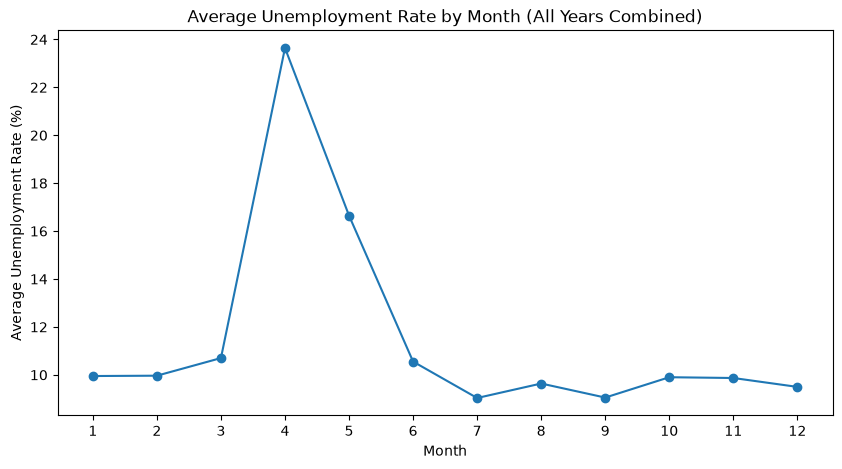

In [33]:
monthly_avg = df.groupby(df["date"].dt.month)["estimated_unemployment_rate_(%)"].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="line", marker="o")
plt.title("Average Unemployment Rate by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1,13))
plt.show()

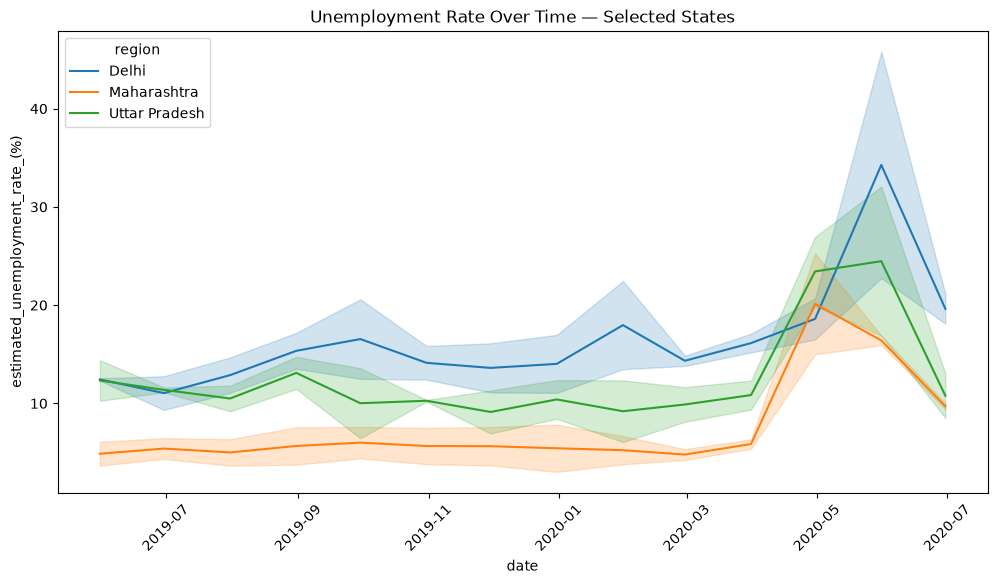

In [34]:
top_states = ["Maharashtra", "Delhi", "Uttar Pradesh"]  # swap for any 3 states actually present in your data — check df["region"].unique() first

subset = df[df["region"].isin(top_states)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=subset, x="date", y="estimated_unemployment_rate_(%)", hue="region")
plt.title("Unemployment Rate Over Time — Selected States")
plt.xticks(rotation=45)
plt.show()

*HEATMAP*

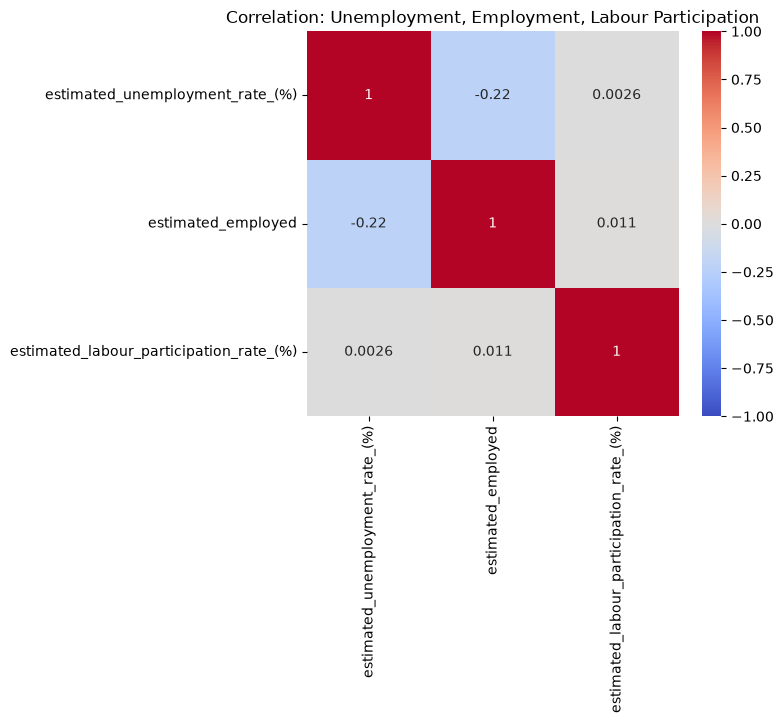

In [35]:
plt.figure(figsize=(6,5))
corr = df[['estimated_unemployment_rate_(%)', 'estimated_employed', 'estimated_labour_participation_rate_(%)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Unemployment, Employment, Labour Participation')
plt.show()

*PREPROCESSING* & *FEATURE ENGI*

In [36]:
df2=df.copy()
df2 = df2.sort_values(['region', 'date']).reset_index(drop=True)
df2.head()

,region,date,frequency,estimated_unemployment_rate_(%),estimated_employed,estimated_labour_participation_rate_(%),area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-05-31,Monthly,6.09,4788661.0,37.45,Urban
2,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
3,Andhra Pradesh,2019-06-30,Monthly,3.80,4824630.0,36.76,Urban
4,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural


*Create time-based features*

In [37]:
df2['year'] = df2['date'].dt.year
df2['month'] = df2['date'].dt.month
df2['quarter'] = df2['date'].dt.quarter

df2['month_sin']=np.sin(2*np.pi*df2['month']/12)
df2['month_cos']=np.cos(2*np.pi*df2['month']/12)

*Create lag features*

In [38]:
TARGET = 'estimated_unemployment_rate_(%)'

group_cols = ['region', 'area']

df2['Lag_1']=(
    df2.groupby(group_cols)[TARGET].shift(1)
)

df2['Lag_2']=(
    df2.groupby(group_cols)[TARGET].shift(2)
)

df2['Lag_3']=(
    df2.groupby(group_cols)[TARGET].shift(3)
)

df2['Lag_6']=(
    df2.groupby(group_cols)[TARGET].shift(6)
)



*Rolling features*

In [39]:
df2['Rolling_Mean_3'] = df2.groupby(group_cols)[TARGET].transform(lambda x: x.shift(1).rolling(3).mean())
df2['Rolling_Mean_6'] = df2.groupby(group_cols)[TARGET].transform(lambda x: x.shift(1).rolling(6).mean())

In [40]:
df2.head()

,region,date,frequency,estimated_unemployment_rate_(%),estimated_employed,estimated_labour_participation_rate_(%),area,year,month,quarter,month_sin,month_cos,Lag_1,Lag_2,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Mean_6
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,2,5.000000e-01,-0.866025,NaN,NaN,NaN,NaN,NaN,NaN
1,Andhra Pradesh,2019-05-31,Monthly,6.09,4788661.0,37.45,Urban,2019,5,2,5.000000e-01,-0.866025,NaN,NaN,NaN,NaN,NaN,NaN
2,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,2,1.224647e-16,-1.000000,3.65,NaN,NaN,NaN,NaN,NaN
3,Andhra Pradesh,2019-06-30,Monthly,3.80,4824630.0,36.76,Urban,2019,6,2,1.224647e-16,-1.000000,6.09,NaN,NaN,NaN,NaN,NaN
4,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,3,-5.000000e-01,-0.866025,3.05,3.65,NaN,NaN,NaN,NaN


In [41]:
df2.isnull().sum()

region                                       0
date                                         0
frequency                                    0
estimated_unemployment_rate_(%)              0
estimated_employed                           0
estimated_labour_participation_rate_(%)      0
area                                         0
year                                         0
month                                        0
quarter                                      0
month_sin                                    0
month_cos                                    0
Lag_1                                       55
Lag_2                                      110
Lag_3                                      165
Lag_6                                      329
Rolling_Mean_3                             165
Rolling_Mean_6                             329
dtype: int64

In [42]:
print("Start Date:", df2['date'].min())
print("End Date:", df2['date'].max())

print("Number of unique dates:", df2['date'].nunique())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00
Number of unique dates: 14


In [43]:
print(sorted(df2['date'].unique()))

[Timestamp('2019-05-31 00:00:00'), Timestamp('2019-06-30 00:00:00'), Timestamp('2019-07-31 00:00:00'), Timestamp('2019-08-31 00:00:00'), Timestamp('2019-09-30 00:00:00'), Timestamp('2019-10-31 00:00:00'), Timestamp('2019-11-30 00:00:00'), Timestamp('2019-12-31 00:00:00'), Timestamp('2020-01-31 00:00:00'), Timestamp('2020-02-29 00:00:00'), Timestamp('2020-03-31 00:00:00'), Timestamp('2020-04-30 00:00:00'), Timestamp('2020-05-31 00:00:00'), Timestamp('2020-06-30 00:00:00')]


*Create the split*

In [44]:
train_df = df2[
    df2['date'] < '2020-04-01'
].copy()

test_df = df2[
    df2['date'] >= '2020-04-01'
].copy()

print("Training period:",
      train_df['date'].min(),
      "to",
      train_df['date'].max())

print("Test period:",
      test_df['date'].min(),
      "to",
      test_df['date'].max())

print("\nShapes:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Training period: 2019-05-31 00:00:00 to 2020-03-31 00:00:00
Test period: 2020-04-30 00:00:00 to 2020-06-30 00:00:00

Shapes:
Train: (588, 18)
Test: (152, 18)


In [45]:

lag_features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_6',
    'Rolling_Mean_3',
    'Rolling_Mean_6'
]

print("Training missing values:")
print(train_df[lag_features].isnull().sum())

print("\nTest missing values:")
print(test_df[lag_features].isnull().sum())

Training missing values:
Lag_1              55
Lag_2             110
Lag_3             165
Lag_6             327
Rolling_Mean_3    165
Rolling_Mean_6    327
dtype: int64

Test missing values:
Lag_1             0
Lag_2             0
Lag_3             0
Lag_6             2
Rolling_Mean_3    0
Rolling_Mean_6    2
dtype: int64


In [46]:
#Baseline Model 1: Naive Forecast

baseline_test = test_df.dropna(subset=['Lag_1']).copy()

y_test = baseline_test[TARGET]
y_pred_naive = baseline_test['Lag_1']

print("Naive Baseline Evaluation Rows:", len(baseline_test))

Naive Baseline Evaluation Rows: 152


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

naive_mae = mean_absolute_error(y_test, y_pred_naive)

naive_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_naive)
)

naive_r2 = r2_score(y_test, y_pred_naive)

print("Naive Baseline Results")
print("----------------------")
print(f"MAE  : {naive_mae:.4f}")
print(f"RMSE : {naive_rmse:.4f}")
print(f"R²   : {naive_r2:.4f}")

Naive Baseline Results
----------------------
MAE  : 14.5572
RMSE : 20.0523
R²   : -0.5465


In [48]:
#Baseline Model 2: 3-Month Moving Average

baseline_ma3 = test_df.dropna(
    subset=['Rolling_Mean_3']
).copy()

y_test_ma3 = baseline_ma3[TARGET]
y_pred_ma3 = baseline_ma3['Rolling_Mean_3']

print("3-Month Moving Average Evaluation Rows:", len(baseline_ma3))

3-Month Moving Average Evaluation Rows: 152


In [49]:
# Evaluate 3-month moving average baseline

ma3_mae = mean_absolute_error(y_test_ma3, y_pred_ma3)

ma3_rmse = np.sqrt(
    mean_squared_error(y_test_ma3, y_pred_ma3)
)

ma3_r2 = r2_score(y_test_ma3, y_pred_ma3)

print("3-Month Moving Average Results")
print("--------------------------------")
print(f"MAE  : {ma3_mae:.4f}")
print(f"RMSE : {ma3_rmse:.4f}")
print(f"R²   : {ma3_r2:.4f}")

3-Month Moving Average Results
--------------------------------
MAE  : 13.3077
RMSE : 18.5132
R²   : -0.3182


In [50]:
baseline_results = pd.DataFrame({
    'Model': [
        'Naive Forecast',
        '3-Month Moving Average'
    ],
    'MAE': [
        naive_mae,
        ma3_mae
    ],
    'RMSE': [
        naive_rmse,
        ma3_rmse
    ],
    'R2': [
        naive_r2,
        ma3_r2
    ]
})

baseline_results

,Model,MAE,RMSE,R2
0,Naive Forecast,14.557171,20.052336,-0.546540
1,3-Month Moving Average,13.307654,18.513213,-0.318241


In [51]:
# Model 3: Linear Regression

TARGET = 'estimated_unemployment_rate_(%)'

features = [
    'region',
    'area',
    'year',
    'month',
    'quarter',
    'month_sin',
    'month_cos',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_6',
    'Rolling_Mean_3',
    'Rolling_Mean_6'
]

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (588, 13)
X_test : (152, 13)


In [52]:
train_lr = train_df.dropna(subset=features).copy()
test_lr = test_df.dropna(subset=features).copy()

X_train = train_lr[features]
y_train = train_lr[TARGET]

X_test = test_lr[features]
y_test = test_lr[TARGET]

print("Usable training rows:", len(train_lr))
print("Usable test rows:", len(test_lr))

Usable training rows: 261
Usable test rows: 150


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical_features = ['region', 'area']

numerical_features = [
    'year',
    'month',
    'quarter',
    'month_sin',
    'month_cos',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_6',
    'Rolling_Mean_3',
    'Rolling_Mean_6'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_features),

        ('numerical',
         StandardScaler(),
         numerical_features)
    ]
)

In [54]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['region','area','year',...,'Lag_6','Rolling_Mean_3','Rolling_Mean_6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [55]:
y_pred_lr = linear_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 13.4021
RMSE : 19.4757
R²   : -0.4627


*RF*

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
---------------------
MAE  : 12.5904
RMSE : 18.1188
R²   : -0.2660


In [57]:
# Walk-forward validation

walk_forward_dates = [
    '2020-01-31',
    '2020-02-29',
    '2020-03-31'
]

print("Walk-forward validation dates:")
for date in walk_forward_dates:
    print(date)

Walk-forward validation dates:
2020-01-31
2020-02-29
2020-03-31


In [58]:
def create_linear_model():
    return Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', LinearRegression())
        ]
    )

In [59]:
wf_results_lr = []

for validation_date in walk_forward_dates:

    validation_date = pd.Timestamp(validation_date)

    wf_train = train_df[
        train_df['date'] < validation_date
    ].copy()

    # One-month validation window
    wf_validation = train_df[
        train_df['date'] == validation_date
    ].copy()

    # Remove rows without sufficient lag history
    wf_train = wf_train.dropna(subset=features)
    wf_validation = wf_validation.dropna(subset=features)

    X_wf_train = wf_train[features]
    y_wf_train = wf_train[TARGET]

    X_wf_validation = wf_validation[features]
    y_wf_validation = wf_validation[TARGET]

    # Create a fresh model
    model = create_linear_model()
    model.fit(X_wf_train, y_wf_train)
    predictions = model.predict(X_wf_validation)

    mae = mean_absolute_error(
        y_wf_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_wf_validation,
            predictions
        )
    )

    wf_results_lr.append({
        'Validation_Date': validation_date,
        'MAE': mae,
        'RMSE': rmse
    })

wf_lr_df = pd.DataFrame(wf_results_lr)

wf_lr_df

,Validation_Date,MAE,RMSE
0,2020-01-31,3.089436,4.232772
1,2020-02-29,2.107425,3.362666
2,2020-03-31,3.009124,4.918103


In [60]:
print("Linear Regression Walk-Forward Performance")
print("--------------------------------------------")

print(f"Mean MAE : {wf_lr_df['MAE'].mean():.4f}")
print(f"Mean RMSE: {wf_lr_df['RMSE'].mean():.4f}")

Linear Regression Walk-Forward Performance
--------------------------------------------
Mean MAE : 2.7353
Mean RMSE: 4.1712


"Linear Regression demonstrated strong performance during walk-forward validation, with a mean MAE of 2.7353. However, performance deteriorated substantially on the final April–June 2020 holdout period, highlighting the difficulty of forecasting during a sudden structural change in unemployment."

In [61]:
# Random Forest Walk-forward

def create_rf_model():
    return Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )

In [62]:
wf_results_rf = []

for validation_date in walk_forward_dates:

    validation_date = pd.Timestamp(validation_date)

    wf_train = train_df[
        train_df['date'] < validation_date
    ].copy()

    wf_validation = train_df[
        train_df['date'] == validation_date
    ].copy()

    wf_train = wf_train.dropna(subset=features)
    wf_validation = wf_validation.dropna(subset=features)

    X_wf_train = wf_train[features]
    y_wf_train = wf_train[TARGET]

    X_wf_validation = wf_validation[features]
    y_wf_validation = wf_validation[TARGET]

    model = create_rf_model()

    model.fit(X_wf_train, y_wf_train)

    predictions = model.predict(X_wf_validation)

    mae = mean_absolute_error(
        y_wf_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_wf_validation,
            predictions
        )
    )

    wf_results_rf.append({
        'Validation_Date': validation_date,
        'MAE': mae,
        'RMSE': rmse
    })

wf_rf_df = pd.DataFrame(wf_results_rf)

wf_rf_df

,Validation_Date,MAE,RMSE
0,2020-01-31,2.418407,3.186939
1,2020-02-29,2.134577,3.246244
2,2020-03-31,2.392797,3.282426


In [63]:
print("Random Forest Walk-Forward Performance")
print("----------------------------------------")

print(f"Mean MAE : {wf_rf_df['MAE'].mean():.4f}")
print(f"Mean RMSE: {wf_rf_df['RMSE'].mean():.4f}")

Random Forest Walk-Forward Performance
----------------------------------------
Mean MAE : 2.3153
Mean RMSE: 3.2385


In [64]:
# Gradient Boosting Walk-forward

from sklearn.ensemble import GradientBoostingRegressor

def create_gb_model():
    return Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42
            ))
        ]
    )

In [65]:
wf_results_gb = []

for validation_date in walk_forward_dates:

    validation_date = pd.Timestamp(validation_date)

    wf_train = train_df[
        train_df['date'] < validation_date
    ].copy()

    # One-month validation window
    wf_validation = train_df[
        train_df['date'] == validation_date
    ].copy()

    # Remove rows without sufficient history
    wf_train = wf_train.dropna(subset=features)
    wf_validation = wf_validation.dropna(subset=features)

    X_wf_train = wf_train[features]
    y_wf_train = wf_train[TARGET]

    X_wf_validation = wf_validation[features]
    y_wf_validation = wf_validation[TARGET]

    # Fresh Gradient Boosting model
    model = create_gb_model()
    model.fit(X_wf_train, y_wf_train)
    predictions = model.predict(X_wf_validation)

    mae = mean_absolute_error(
        y_wf_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_wf_validation,
            predictions
        )
    )

    wf_results_gb.append({
        'Validation_Date': validation_date,
        'MAE': mae,
        'RMSE': rmse
    })

wf_gb_df = pd.DataFrame(wf_results_gb)

wf_gb_df

,Validation_Date,MAE,RMSE
0,2020-01-31,2.351411,3.079262
1,2020-02-29,2.349574,3.876679
2,2020-03-31,2.682342,3.573868


In [66]:
print("Gradient Boosting Walk-Forward Performance")
print("-------------------------------------------")

print(f"Mean MAE : {wf_gb_df['MAE'].mean():.4f}")
print(f"Mean RMSE: {wf_gb_df['RMSE'].mean():.4f}")

Gradient Boosting Walk-Forward Performance
-------------------------------------------
Mean MAE : 2.4611
Mean RMSE: 3.5099


In [67]:
walk_forward_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean_MAE': [
        wf_lr_df['MAE'].mean(),
        wf_rf_df['MAE'].mean(),
        wf_gb_df['MAE'].mean()
    ],
    'Mean_RMSE': [
        wf_lr_df['RMSE'].mean(),
        wf_rf_df['RMSE'].mean(),
        wf_gb_df['RMSE'].mean()
    ]
})

walk_forward_comparison = walk_forward_comparison.sort_values(
    'Mean_MAE'
).reset_index(drop=True)

walk_forward_comparison

,Model,Mean_MAE,Mean_RMSE
0,Random Forest,2.315260,3.238536
1,Gradient Boosting,2.461109,3.509937
2,Linear Regression,2.735329,4.171180


In [68]:
# Final model

final_rf_model = create_rf_model()

final_train = train_df.dropna(subset=features).copy()
final_test = test_df.dropna(subset=features).copy()

X_final_train = final_train[features]
y_final_train = final_train[TARGET]

X_final_test = final_test[features]
y_final_test = final_test[TARGET]

final_rf_model.fit(X_final_train, y_final_train)
final_predictions = final_rf_model.predict(X_final_test)

final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_final_test,
    final_predictions
)

print("FINAL RANDOM FOREST TEST RESULTS")
print("---------------------------------")
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

FINAL RANDOM FOREST TEST RESULTS
---------------------------------
MAE  : 12.5904
RMSE : 18.1188
R²   : -0.2660


In [69]:
final_comparison = pd.DataFrame({
    'Model': [
        'Naive Forecast',
        '3-Month Moving Average',
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        naive_mae,
        ma3_mae,
        lr_mae,
        final_mae
    ],
    'RMSE': [
        naive_rmse,
        ma3_rmse,
        lr_rmse,
        final_rmse
    ],
    'R2': [
        naive_r2,
        ma3_r2,
        lr_r2,
        final_r2
    ]
})

final_comparison.sort_values(
    'MAE'
).reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Random Forest,12.590434,18.118772,-0.266000
1,3-Month Moving Average,13.307654,18.513213,-0.318241
2,Linear Regression,13.402117,19.475658,-0.462718
3,Naive Forecast,14.557171,20.052336,-0.546540


In [70]:
# Final results

results_df = final_test[
    ['region', 'area', 'date', TARGET]
].copy()

results_df['Predicted'] = final_predictions

results_df['Error'] = (
    results_df[TARGET] -
    results_df['Predicted']
)

results_df['Absolute_Error'] = (
    results_df['Error'].abs()
)

results_df.head()

,region,area,date,estimated_unemployment_rate_(%),Predicted,Error,Absolute_Error
22,Andhra Pradesh,Rural,2020-04-30,16.29,4.714924,11.575076,11.575076
23,Andhra Pradesh,Urban,2020-04-30,32.30,7.192711,25.107289,25.107289
24,Andhra Pradesh,Rural,2020-05-31,14.46,8.065661,6.394339,6.394339
25,Andhra Pradesh,Urban,2020-05-31,24.91,11.828246,13.081754,13.081754
26,Andhra Pradesh,Rural,2020-06-30,0.85,7.485378,-6.635378,6.635378


In [71]:
actual_predicted_monthly = (
    results_df
    .groupby('date')[[TARGET, 'Predicted']]
    .mean()
    .reset_index()
)

actual_predicted_monthly

,date,estimated_unemployment_rate_(%),Predicted
0,2020-04-30,24.114400,9.974052
1,2020-05-31,24.875294,13.023786
2,2020-06-30,12.027959,15.669858


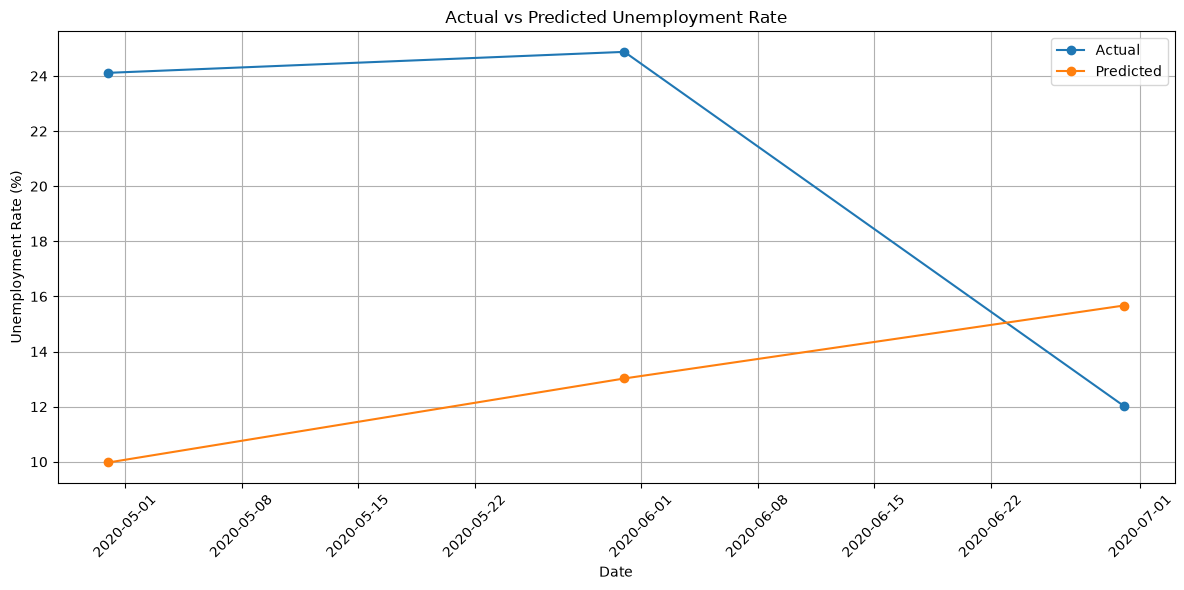

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    actual_predicted_monthly['date'],
    actual_predicted_monthly[TARGET],
    marker='o',
    label='Actual'
)

plt.plot(
    actual_predicted_monthly['date'],
    actual_predicted_monthly['Predicted'],
    marker='o',
    label='Predicted'
)

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Actual vs Predicted Unemployment Rate')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
# Error Analysis
print("Error Analysis")
print("--------------")

print(f"Mean Error       : {results_df['Error'].mean():.4f}")
print(f"Mean Absolute Error: {results_df['Absolute_Error'].mean():.4f}")
print(f"Maximum Error    : {results_df['Absolute_Error'].max():.4f}")

Error Analysis
--------------
Mean Error       : 7.5533
Mean Absolute Error: 12.5904
Maximum Error    : 74.4615


In [74]:
region_area_error = (
    results_df
    .groupby(['region', 'area'])
    .agg(
        Actual_Mean=(TARGET, 'mean'),
        Predicted_Mean=('Predicted', 'mean'),
        MAE=('Absolute_Error', 'mean')
    )
    .reset_index()
    .sort_values('MAE', ascending=False)
)

region_area_error.head(10)

,region,area,Actual_Mean,Predicted_Mean,MAE
35,Puducherry,Rural,74.510000,1.939634,72.570366
36,Puducherry,Urban,52.096667,14.554700,50.760616
22,Jharkhand,Urban,50.343333,22.011328,32.463699
42,Tamil Nadu,Rural,31.326667,13.324319,30.511224
21,Jharkhand,Rural,39.450000,16.334133,24.617563
5,Bihar,Urban,36.363333,21.122702,22.929915
4,Bihar,Rural,37.613333,18.202376,21.504879
18,Himachal Pradesh,Urban,21.170000,26.056002,20.402711
43,Tamil Nadu,Urban,32.143333,13.810805,18.332529
1,Andhra Pradesh,Urban,21.023333,13.200139,17.636168


In [75]:
import joblib

model_path = 'unemployment_random_forest_final.pkl'

joblib.dump(
    final_rf_model,
    model_path
)

print(f"Final model saved as: {model_path}")

Final model saved as: unemployment_random_forest_final.pkl


In [76]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(
    X_final_test
)

print(
    "Loaded model prediction check:",
    np.allclose(
        final_predictions,
        loaded_predictions
    )
)

Loaded model prediction check: True
